In [125]:
# iterative_workflow

from dotenv import load_dotenv
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


In [136]:
load_dotenv()

str_parser = StrOutputParser()

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=1,
)

# llm = ChatGoogleGenerativeAI(
#     model="gemini-3.5-flash",
#     temperature=0.1,
# )

llm.invoke("hi").content

'Hi there! How can I help you today?'

In [137]:
class EvaluatorStatus(BaseModel):
    feedback: str = Field(description = "The feedback about the topic")
    status: Literal["not-approved", "approved"] = Field(description = "The status of the feedback, whether it is approved or not approved")
        
class LLMState(TypedDict):
    topic: str
    quote: str
    evaluation: dict
    iterator: int

In [138]:
structured_llm = llm.with_structured_output(EvaluatorStatus, method="json_schema")

In [139]:
# Generate Quote
def generate_quote(state: LLMState):
    topic = state["topic"]
    quote_generator_prompt = f"""
    Generate ONE unique, funny, creative, and shareable quote about: {topic}

    Requirements:
    - Dont go with question answer workflow, just generate a quote.
    - Fresh and original; avoid ordinary or overused quotes.
    - Avoid clichés, generic motivation, and predictable life advice.
    - Use clever humor, irony, wordplay, unexpected comparisons, or relatable situations.
    - Should feel natural and human-written, not AI-generated.
    - Modern/trendy when appropriate, but don't force trends.
    - Concise: preferably 1-2 sentences.
    - Don't copy or paraphrase famous quotes.
    - Return ONLY the quote.

    Make it something people would actually want to share.
    """
    
    quote = llm.invoke(quote_generator_prompt)
    quote = str_parser.parse(quote)

    print(f"Generated Quote: {quote}")
    return {"quote": quote}


In [140]:
# Evaluate Quote
def eval_quote(state: LLMState):
    topic = state["topic"]
    quote = state["quote"]
    print(f"Evaluating started")
    quote_evaluator_prompt = f"""
        Evaluate this quote strictly:

        Quote: {quote}
        Topic: {topic}

        Check:
        - Originality / uniqueness
        - Cliché or overused wording
        - Humor / wit
        - Relatability
        - Natural, human-like writing
        - Creativity
        - Shareability
        - Current/trending relevance
        - Similarity to famous/common quotes

        Do not claim it is absolutely unused unless verified externally.
        Judge whether it FEELS original and is unlikely to be overused.

        Return:
        - score: 0-10
        - feedback: brief, specific explanation
        - decision: exactly "approved" or "not-approved"

        Approve only if score >= 8 and there is no major issue with originality,
        humor, cliché level, or naturalness.
        """
        
    iteration = state["iterator"]

    evaluation = structured_llm.invoke(quote_evaluator_prompt)
    state['iterator'] = iteration + 1

    print(f"Evaluation Feedback: {evaluation}")
    print(f"Evaluation Iteration: {state['iterator']}")
    status = "approved" if state['iterator'] >= 3 or evaluation.status == "approved" else "not-approved"
    return {"evaluation": {"feedback": evaluation.feedback, "status": status}, "iterator": state['iterator']}

In [141]:
def final_response(state: LLMState) -> LLMState:
    return state

In [142]:
# Define the condition function to determine which response generation function to call based on sentiment
def status_condition(state: LLMState) -> Literal["final_response", "generate_quote"]:
    status = state["evaluation"]["status"]
    if status == "approved":
        return "final_response"
    else:
        return "generate_quote"

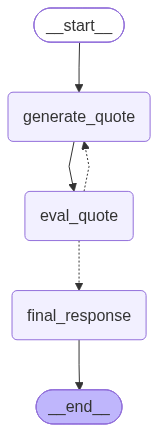

In [143]:
# intialize graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node("generate_quote", generate_quote)
graph.add_node("eval_quote", eval_quote)
graph.add_node("final_response", final_response)

# add edges
graph.add_edge(START, "generate_quote")
graph.add_edge("generate_quote", "eval_quote")
graph.add_conditional_edges("eval_quote", status_condition)
graph.add_edge("final_response", END)

# compile the graph into workflow
workflow = graph.compile()
workflow

In [144]:
topic = "World"
result = workflow.invoke({"topic": topic, "iterator": 0})
result

Generated Quote: content="The world runs on a mix of caffeine, unspoken anxiety, and the sheer collective agreement to pretend that 4:59 PM isn't actually 5:00 AM." additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 170, 'total_tokens': 208, 'completion_time': 0.071897703, 'completion_tokens_details': None, 'prompt_time': 0.011817997, 'prompt_tokens_details': None, 'queue_time': 0.048706473, 'total_time': 0.0837157}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a0b3e4-76a1-7d93-b29d-f1ce2b57e49c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 170, 'output_tokens': 38, 'total_tokens': 208}
Evaluating started
Evaluation Feedback: feedback="The quote suffers from a significant grammatical and logical flaw in its final clause: 'pretend that 4:59 PM isn't actually 5:00 AM.' This compa

{'topic': 'World',
 'quote': AIMessage(content='The Earth only spins to keep us from seeing the same sunspot all day, and we’re too busy checking notifications to notice that.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 170, 'total_tokens': 198, 'completion_time': 0.053133972, 'completion_tokens_details': None, 'prompt_time': 0.011707232, 'prompt_tokens_details': None, 'queue_time': 0.047938678, 'total_time': 0.064841204}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b3e4-7aa6-7053-924a-1637fcc8d8cc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 28, 'total_tokens': 198}),
 'evaluation': {'feedback': "The quote relies on a pseudoscientific setup (Earth spinning specifically to hide sunspots) that is factually incorrect and undermines the poet